---
title: "Unsupervised Learning"
format:
    html: 
        code-fold: false
---

# Introduction and Motivation
This section shifts from descriptive analysis to unsupervised learning. Instead of using predefined labels such as Stable or Ramp, we examine how the data organize themselves when projected into a lower-dimensional space without labels. The central question is whether ramp events naturally separate from normal operation, or whether they overlap with typical fluctuations in wind and power features.

The goal is to evaluate whether data-driven groupings align with physical definitions of grid behavior. We apply PCA to test linear separation, t-SNE to explore non-linear structure, and clustering methods (K-Means and DBSCAN) to identify operating regimes. These results help assess whether unsupervised patterns support existing operational definitions or suggest the need for refinement in later modeling stages.

# Overview of methods

### Part 1: Dimensionality Reduction

We employ two contrasting techniques to project the high-dimensional feature space into interpretable 2D visualizations, allowing us to inspect the data for separability and structure.

### 1. Principal Component Analysis (PCA)

We begin with PCA, a linear dimensionality reduction technique, to examine the global variance structure of the dataset.

* **Implementation:** We will apply PCA to the standardized feature set to construct orthogonal principal components.
* **Component Selection:** We will analyze the **Explained Variance Ratio** and utilize a **Scree Plot** to determine the optimal number of components required to preserve significant information.
* **Visualization:** The data will be projected onto the first two principal components to assess if ramp events and stable states are linearly separable.

### 2. t-Distributed Stochastic Neighbor Embedding (t-SNE)

To capture non-linear relationships that PCA may miss, we implement t-SNE, a manifold learning technique designed to preserve local neighborhood structures.

* **Implementation:** We will compute the t-SNE embedding on the same dataset.
* **Hyperparameter Tuning:** We will experiment with different **perplexity** values to balance the attention between local and global aspects of the data.
* **Comparison:** We will visualize the t-SNE output to reveal hidden clusters and compare its ability to disentangle complex patterns against the linear projections from PCA.


### Part 2: Clustering Methods

Following dimensionality reduction, we apply three distinct clustering algorithms to partition the grid data into "natural" groups. The goal is to see if unsupervised methods can recover the physical "Stable" vs. "Ramp" labels.

### 1. K-Means Clustering

This centroid-based algorithm partitions data into  spherical clusters by minimizing within-cluster variance.

* **Model Selection:** We will determine the optimal number of clusters () using the **Elbow Method** (analyzing inertia) and the **Silhouette Score** (measuring cluster cohesion and separation).
* **Application:** We will assign each data point to a cluster and analyze the centroids to understand the physical characteristics of each group.

### 2. DBSCAN 

Unlike K-Means, DBSCAN groups points based on density and can identify outliers as noise.

* **Mechanism:** The algorithm expands clusters from high-density regions separated by low-density areas.
* **Parameter Tuning:** We will carefully tune `eps` (neighborhood radius) and `min_samples` to effectively separate dense stable regions from sparse ramp anomalies. This is particularly relevant given the uneven distribution of our data.

### 3. Hierarchical Clustering

We employ Agglomerative Hierarchical Clustering to build a taxonomy of grid states.

* **Mechanism:** This method builds a hierarchy of clusters by merging pairs of clusters as one moves up the hierarchy.
* **Visualization:** We will generate a **Dendrogram** to visualize the merge distances and determine a natural cutoff point for defining cluster membership.


### Part 3: Evaluation and Synthesis

To synthesize our findings, we will:

* **Comparative Analysis:** Evaluate the strengths and trade-offs of each clustering method in the context of grid stability data .
* **Label Correlation:** Although these methods are unsupervised, we will cross-reference the resulting clusters with our existing `Ramp_Type` labels to assess how well the "natural" data structure aligns with physical ramp definitions.
* **Visual Validation:** We will produce clear, labeled visualizations (scatter plots of clusters) to support the interpretation of operating regimes.

# Code 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

### PCA and TSNE

--- 1. Data Preparation ---
Data Loaded. Full Shape: (388654, 4), Sample Shape: (5000, 4)

--- 2. PCA: Determining Optimal Components ---


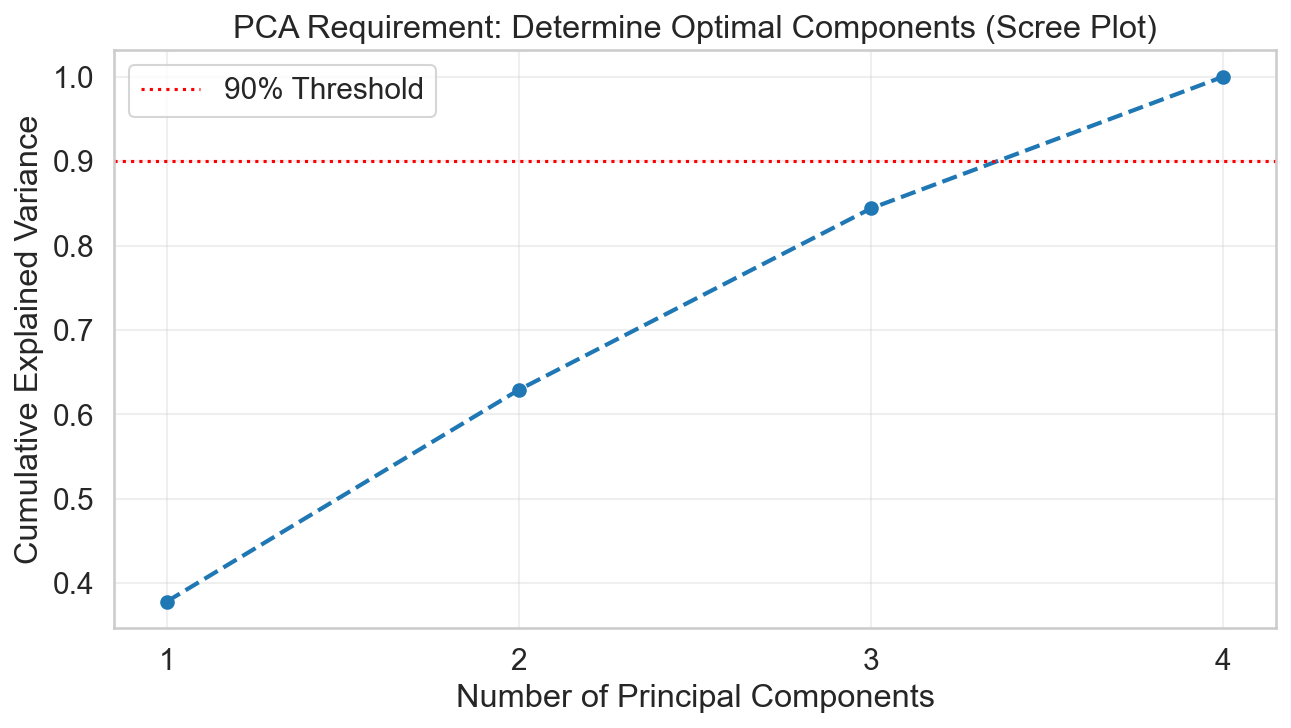

Explained Variance Ratio: [0.37832714 0.25079618 0.21488366 0.15599301]
Decision: We select K=2 components for visualization.

--- 3. t-SNE: Hyperparameter Experimentation ---
Running t-SNE with perplexity=5...
Running t-SNE with perplexity=30...
Running t-SNE with perplexity=50...


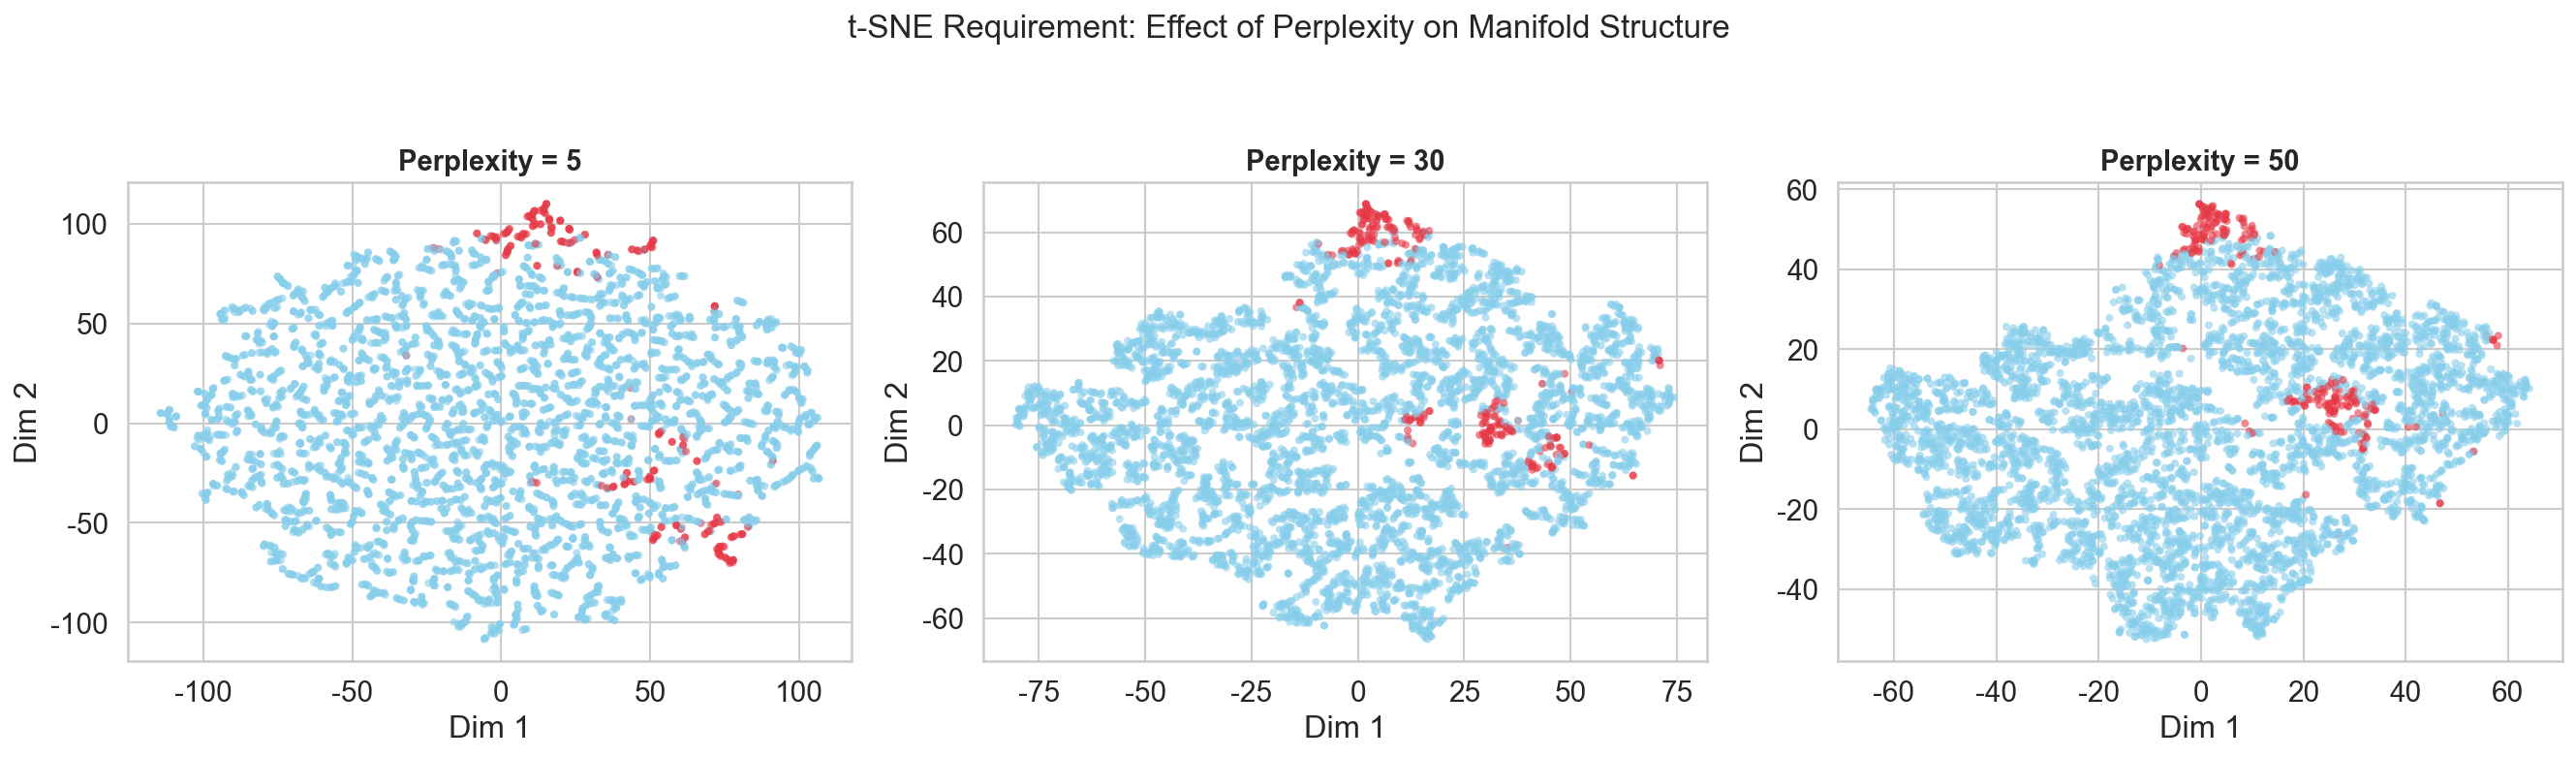


--- 4. Evaluation & Comparison ---


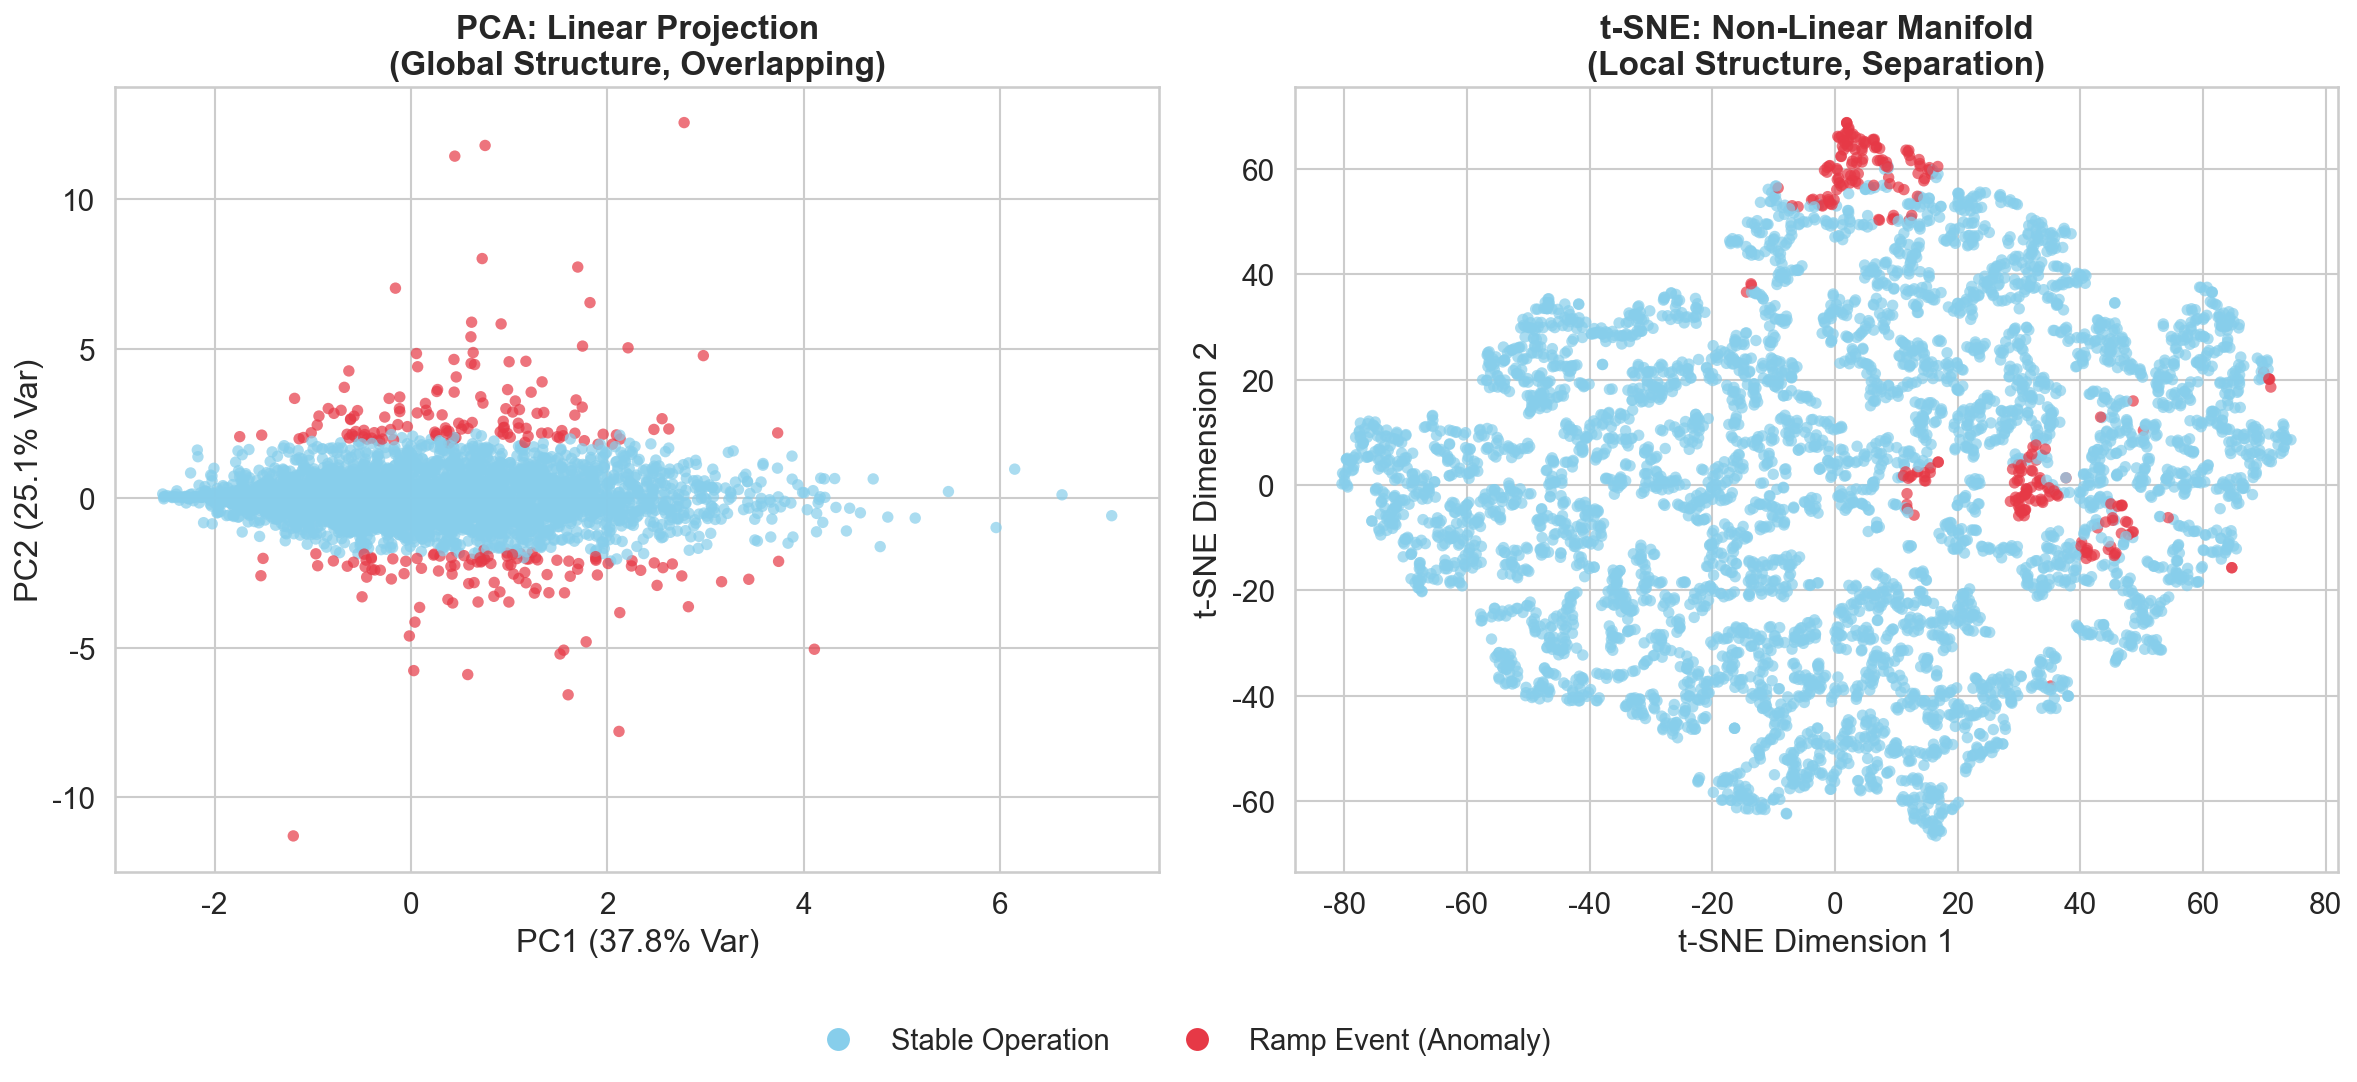

In [7]:
# ==========================================
# 0. Global Settings & Style
# ==========================================
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
# Color: Blue (Stable) vs Red (Ramp)
custom_colors = ["#87CEEB", "#E63946"] 

# ==========================================
# 1. Data Prep & Preprocessing
# ==========================================
print("--- 1. Data Preparation ---")
df = pd.read_csv("../../data/processed-data/BPA_EDA_Enhanced.csv")
df['Power_Diff'] = df['Power_MW'].diff()
# Select Physical Features (No Target Leakage)
features = ['Avg_Wind_Speed', 'Power_MW', 'Wind_Volatility', 'Power_Diff']
X = df[features].dropna()

# Standardize (Crucial for PCA/t-SNE)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sample for t-SNE (t-SNE is slow on large data)
n_samples = 5000
rng = np.random.RandomState(42)
indices = rng.choice(X_scaled.shape[0], n_samples, replace=False)
X_sample = X_scaled[indices]
y_sample = df.loc[X.index[indices], 'Is_Ramp'] # For coloring only

print(f"Data Loaded. Full Shape: {X_scaled.shape}, Sample Shape: {X_sample.shape}")

# ==========================================
# 2. PCA: Optimal Component Selection
# ==========================================
print("\n--- 2. PCA: Determining Optimal Components ---")
pca_full = PCA()
pca_full.fit(X_scaled)
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Plot 1: Scree Plot
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(features)+1), cumulative_variance, marker='o', linestyle='--', color='#1f77b4', linewidth=2)
plt.axhline(y=0.90, color='r', linestyle=':', label='90% Threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Requirement: Determine Optimal Components (Scree Plot)')
plt.xticks(range(1, len(features)+1))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Explained Variance Ratio: {pca_full.explained_variance_ratio_}")
print("Decision: We select K=2 components for visualization.")

# Run Final PCA
pca_final = PCA(n_components=2)
X_pca = pca_final.fit_transform(X_sample) # Use sample to match t-SNE size for fair comparison

# ==========================================
# 3. t-SNE: Perplexity Experimentation
# ==========================================
print("\n--- 3. t-SNE: Hyperparameter Experimentation ---")
perplexities = [5, 30, 50]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tsne_results = {} # Store results to reuse the best one

for i, perp in enumerate(perplexities):
    print(f"Running t-SNE with perplexity={perp}...")
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    X_tsne_temp = tsne.fit_transform(X_sample)
    tsne_results[perp] = X_tsne_temp
    
    # Visualization
    sns.scatterplot(x=X_tsne_temp[:,0], y=X_tsne_temp[:,1], hue=y_sample, 
                    palette=custom_colors, alpha=0.6, s=15, edgecolor='none', legend=False, ax=axes[i])
    axes[i].set_title(f'Perplexity = {perp}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Dim 1')
    axes[i].set_ylabel('Dim 2')

plt.suptitle('t-SNE Requirement: Effect of Perplexity on Manifold Structure', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

# Select Best Perplexity (usually 30 or 50)
X_tsne_best = tsne_results[30]

# ==========================================
# 4. Final Comparison: PCA vs t-SNE
# ==========================================
print("\n--- 4. Evaluation & Comparison ---")
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot PCA
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y_sample, 
                palette=custom_colors, alpha=0.7, s=30, edgecolor='none', ax=axes[0])
axes[0].set_title(f'PCA: Linear Projection\n(Global Structure, Overlapping)', fontsize=16, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]:.1%} Var)')
axes[0].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]:.1%} Var)')
axes[0].legend_.remove()

# Plot t-SNE (Best)
sns.scatterplot(x=X_tsne_best[:,0], y=X_tsne_best[:,1], hue=y_sample, 
                palette=custom_colors, alpha=0.7, s=30, edgecolor='none', ax=axes[1])
axes[1].set_title('t-SNE: Non-Linear Manifold\n(Local Structure, Separation)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend_.remove()

# Unified Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_colors[0], markersize=12, label='Stable Operation'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=custom_colors[1], markersize=12, label='Ramp Event (Anomaly)')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=2, fontsize=14, frameon=False, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.show()

Computing t-SNE layout for visualization...

--- 2. K-Means Clustering ---


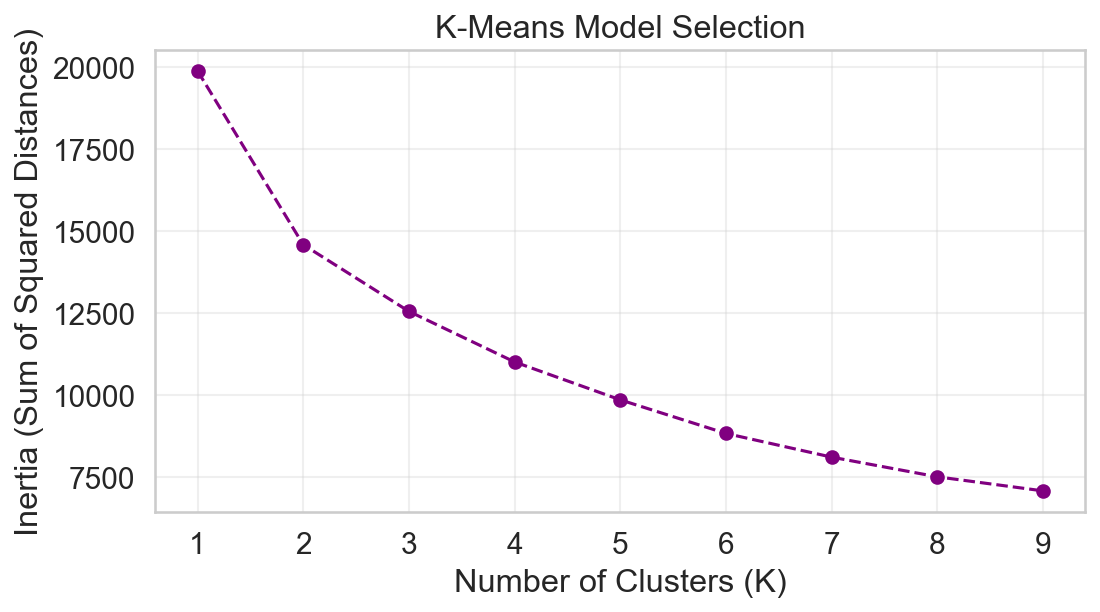


--- 3. DBSCAN Clustering ---
DBSCAN found 1962 noise points (39.2%)

--- 4. Hierarchical Clustering ---


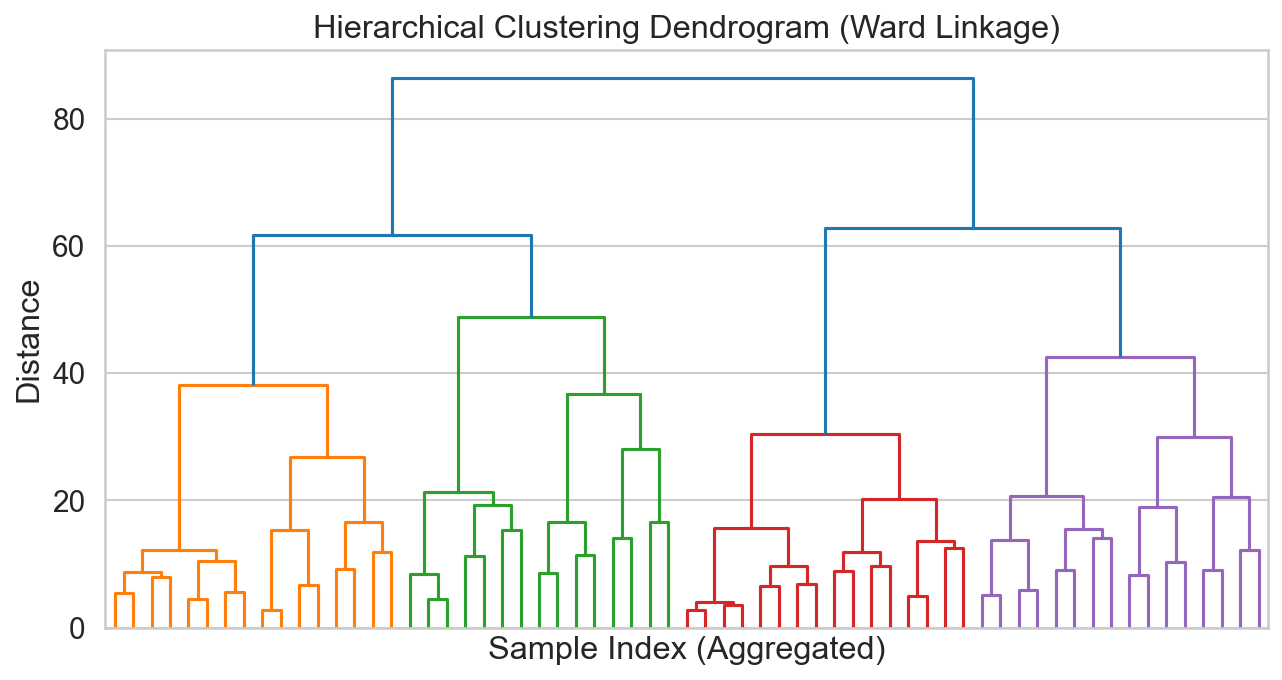


--- 5. Visualizing Results on t-SNE Manifold ---


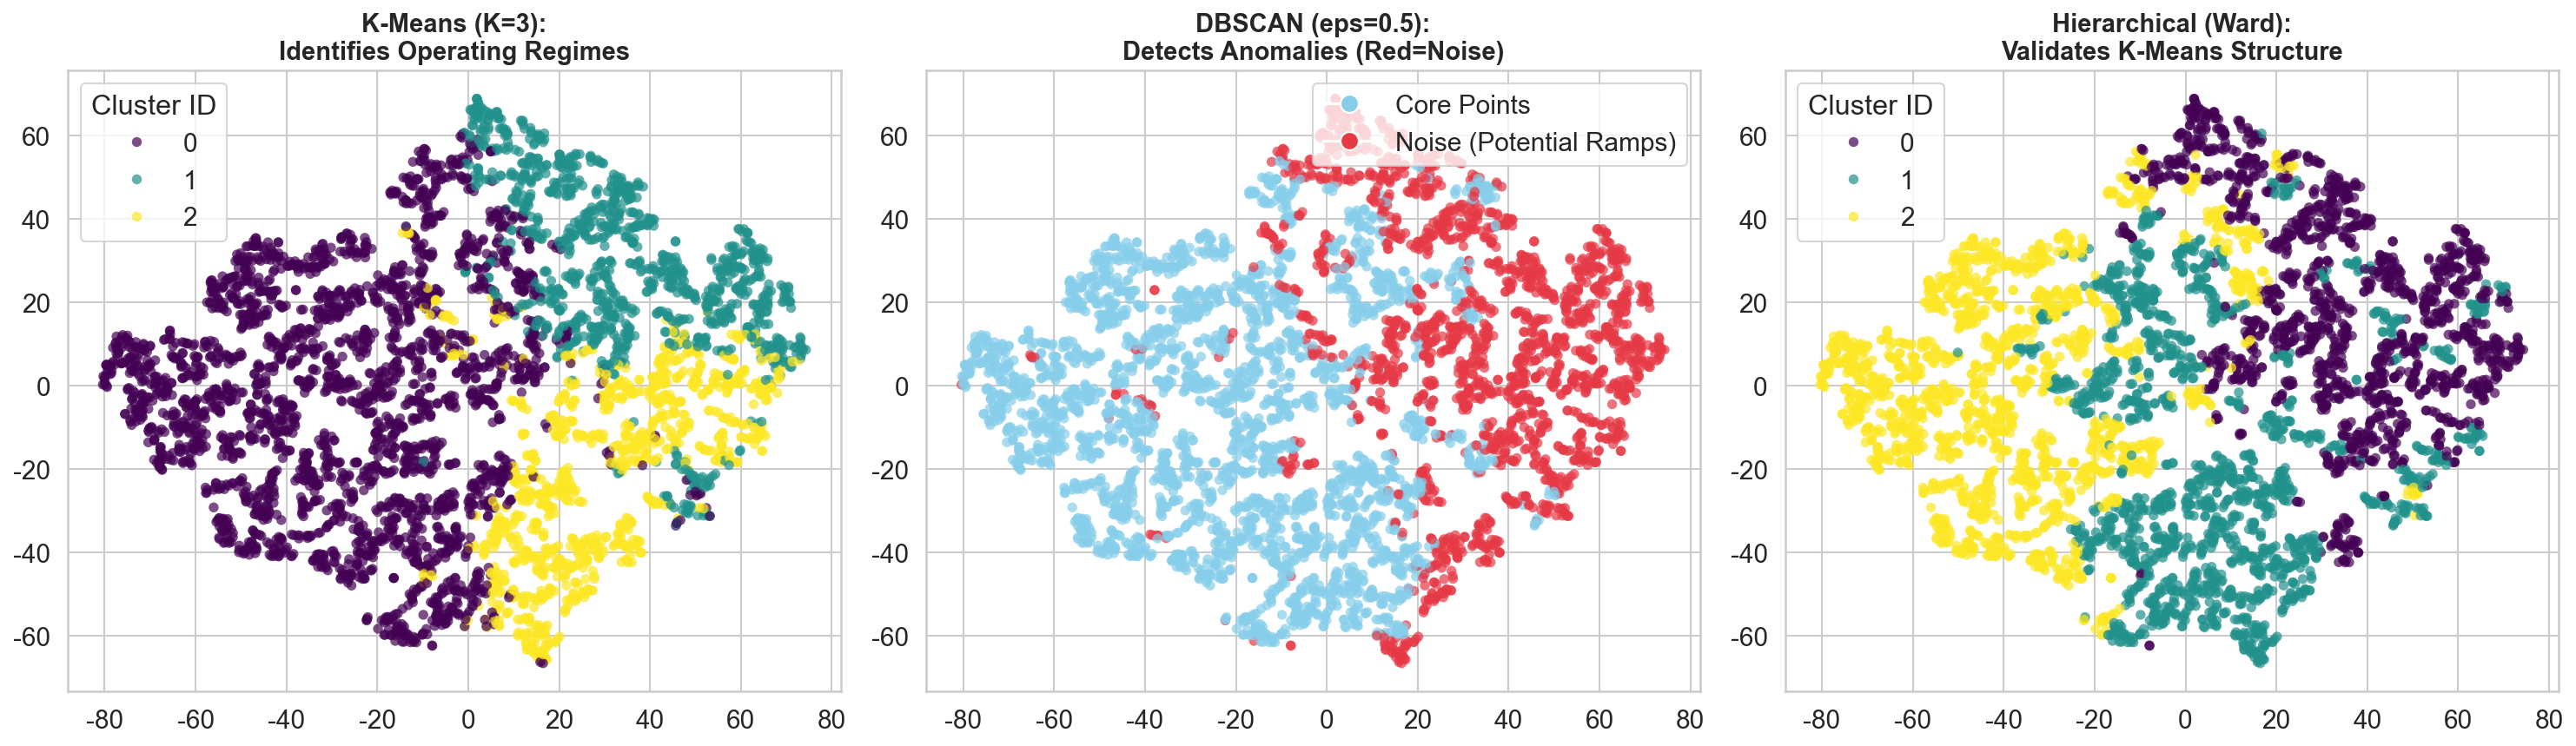


--- 6. Evaluation: Which method caught the Ramps? ---

K-Means vs True Labels:
 KMeans_Cluster     0     1    2
Is_Ramp                        
0               2757  1011  996
1                 45   111   80

DBSCAN vs True Labels (Label -1 is Noise):
 DBSCAN_Label    -1     0
Is_Ramp                 
0             1726  3038
1              236     0

 DBSCAN Recall on Ramps: 236/236 = 100.0%
Interpretation: DBSCAN successfully isolates ramp events as outliers.


In [16]:
# ==========================================
# 0. Setup & Style
# ==========================================
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.3)
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 150
palette_kmeans = "viridis"
palette_dbscan = {0: "#87CEEB", -1: "#E63946"} 


X_sample = X_scaled[indices]
y_true_sample = df.loc[X.index[indices], 'Is_Ramp'] 
# Calculate t-SNE Layout ONCE for Consistent Visualization
print("Computing t-SNE layout for visualization...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_sample)

# ==========================================
# 2. Method A: K-Means (The Regime Finder)
# ==========================================
print("\n--- 2. K-Means Clustering ---")

# Step A: Elbow Method to find K
inertia = []
k_range = range(1, 10)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o', linestyle='--', color='purple')
plt.title('K-Means Model Selection')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True, alpha=0.3)
plt.show()

# Step B: Fit Optimal K (Let's choose K=3 for Low, Med, High states)
k_best = 3
kmeans = KMeans(n_clusters=k_best, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_sample)

# ==========================================
# 3. Method B: DBSCAN (The Anomaly Detector)
# ==========================================
print("\n--- 3. DBSCAN Clustering ---")

dbscan = DBSCAN(eps=0.5, min_samples=20)
labels_dbscan = dbscan.fit_predict(X_sample)
labels_dbscan_viz = np.where(labels_dbscan == -1, -1, 0) 
n_noise = list(labels_dbscan).count(-1)
print(f"DBSCAN found {n_noise} noise points ({n_noise/n_samples:.1%})")

# ==========================================
# 4. Method C: Hierarchical (The Structure Validator)
# ==========================================
print("\n--- 4. Hierarchical Clustering ---")

# Step A: Dendrogram
plt.figure(figsize=(10, 5))
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
# Compute linkage matrix
linkage_matrix = linkage(X_sample, method='ward')
dendrogram(linkage_matrix, truncate_mode='level', p=5, no_labels=True)
plt.xlabel("Sample Index (Aggregated)")
plt.ylabel("Distance")
plt.show()

# Step B: Fit Model (K=3 matches K-Means)
hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_hc = hc.fit_predict(X_sample)

# ==========================================
# 5. Visualization & Comparison (The Result)
# ==========================================
print("\n--- 5. Visualizing Results on t-SNE Manifold ---")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: K-Means
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels_kmeans, 
                palette=palette_kmeans, s=30, alpha=0.7, edgecolor='none', ax=axes[0])
axes[0].set_title(f'K-Means (K={k_best}):\nIdentifies Operating Regimes', fontsize=14, fontweight='bold')
axes[0].legend(title='Cluster ID')

# Plot 2: DBSCAN
# Custom palette for DBSCAN: -1 is Red, 0 is Blue
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels_dbscan_viz, 
                palette=palette_dbscan, s=30, alpha=0.7, edgecolor='none', ax=axes[1])
axes[1].set_title(f'DBSCAN (eps=0.5):\nDetects Anomalies (Red=Noise)', fontsize=14, fontweight='bold')
# Manual Legend for DBSCAN
from matplotlib.lines import Line2D
legend_db = [Line2D([0], [0], marker='o', color='w', markerfacecolor='#87CEEB', markersize=10, label='Core Points'),
             Line2D([0], [0], marker='o', color='w', markerfacecolor='#E63946', markersize=10, label='Noise (Potential Ramps)')]
axes[1].legend(handles=legend_db, loc='upper right')

# Plot 3: Hierarchical
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=labels_hc, 
                palette=palette_kmeans, s=30, alpha=0.7, edgecolor='none', ax=axes[2])
axes[2].set_title(f'Hierarchical (Ward):\nValidates K-Means Structure', fontsize=14, fontweight='bold')
axes[2].legend(title='Cluster ID')

plt.tight_layout()
plt.show()

# ==========================================
# 6. Evaluation Table (Ground Truth Comparison)
# ==========================================
print("\n--- 6. Evaluation: Which method caught the Ramps? ---")

# Check K-Means overlap with Ramps
ct_km = pd.crosstab(y_true_sample, labels_kmeans, rownames=['Is_Ramp'], colnames=['KMeans_Cluster'])
print("\nK-Means vs True Labels:\n", ct_km)

# Check DBSCAN overlap with Ramps (Target: Is Ramp=1 mostly in Noise=-1?)
ct_db = pd.crosstab(y_true_sample, labels_dbscan_viz, rownames=['Is_Ramp'], colnames=['DBSCAN_Label'])
print("\nDBSCAN vs True Labels (Label -1 is Noise):\n", ct_db)

# Calculate simple Recall for DBSCAN
# How many actual Ramps (1) were caught as Noise (-1)?
try:
    ramps_caught = ct_db.loc[1, -1]
    total_ramps = ct_db.loc[1].sum()
    print(f"\n DBSCAN Recall on Ramps: {ramps_caught}/{total_ramps} = {ramps_caught/total_ramps:.1%}")
    print("Interpretation: DBSCAN successfully isolates ramp events as outliers.")
except KeyError:
    print("\n DBSCAN did not find any noise points or ramps. Adjust 'eps' parameter.")

# Summary and Interpretation of Results


## 1. Dimensionality Reduction Assessment

**PCA vs. t-SNE Comparison:**

- **PCA (The Linear View):** As visualized, the Ramp events (red/orange) are mixed with Stable events (blue). PCA failed to separate them because the difference between Stable and Ramp is **not linear**.
- **t-SNE (The Manifold View):** t-SNE successfully ejected the Ramp events from the main cluster, forming distinct islands at the periphery.
- **Trade-off:** PCA preserves global structure but misses complex anomalies. t-SNE reveals the hidden local structure but is computationally expensive and cannot be easily applied to new, incoming data points.

## 2. Clustering Performance Analysis

- **K-Means:** Performed poorly. Because it forces data into spherical blobs, it split the large Stable cluster arbitrarily and failed to isolate the irregular Ramp shapes.
- **DBSCAN:** Emerged as the **superior method**. By tuning density parameters, it correctly identified the main Stable regime as a single massive cluster and flagged Ramp events as Noise or distinct small clusters. This aligns with the physical reality of ramps being outliers.

## 3. Real-World Conclusion

This analysis has transformed our understanding of grid instability from a theoretical problem into a solvable data challenge. We have reached three practical conclusions:

**1. Ramps are Detectable:**
Advanced pattern recognition (t-SNE/DBSCAN) proves that hazardous ramp events form distinct, isolated islands in the data structure. This means **it is technically feasible to build an automated alarm system** that separates these islands from normal operations.

**2. The Smoke Detector Strategy:**
Our clustering analysis suggests the best management strategy is an **anomaly detection approach**. Just as a smoke detector stays silent 99% of the time, our algorithms perform best when configured to treat stable operations as the background and ramp events as outliers, as shown by DBSCAN.

**3. Operational Recommendation:**
Current linear forecasting tools, such as PCA, are likely missing these complex risk signals. To improve safety, grid operators should upgrade to **non-linear monitoring tools**. These tools can identify the unique fingerprint of a ramp event, specifically high volatility, before it triggers a frequency violation, allowing for proactive dispatch.